In [ ]:
#!conda env list

In [ ]:
# !pip install -e /Users/safishajjouz/GitHub/QuantitativePortfolioManagement

In [1]:
import pandas as pd
import numpy as np
from pyData.getdata import get_US_yields, get_FX_spots
import seaborn as sns
import quantstats as qs
import os
import matplotlib.pyplot as plt; plt.rcdefaults()

In [2]:
from myPortfolioManagement.myData import get_stock_prices
from myPortfolioManagement.myDataPreparation import make_sma
from myPortfolioManagement.myBacktesting import performance
from myPortfolioManagement.myPerformanceMetrics import performance_overview, get_main_stats
from myPortfolioManagement.myPlots import monthly_heatmap

<AxesSubplot: xlabel='Date'>

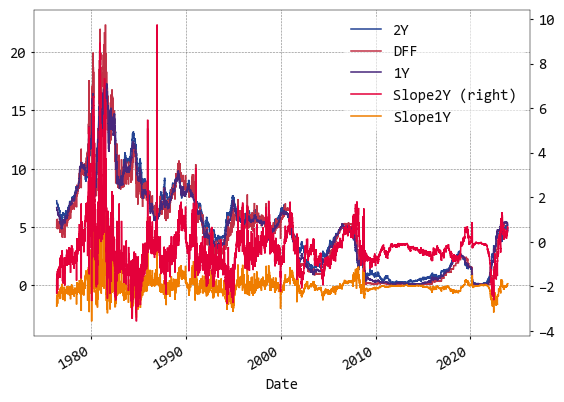

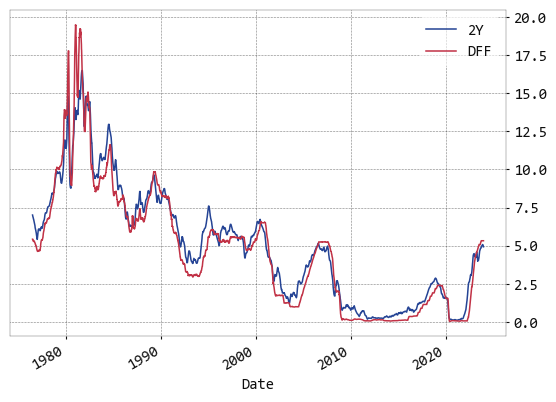

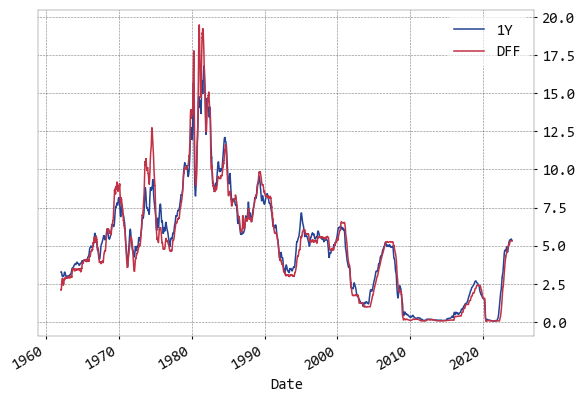

In [3]:
from myPortfolioManagement.myReturns import returns_from_prices

# download US Yields
# ======================================================================================================================
df_USyields = get_US_yields(freq='d', add_fed_rate=True)

# define slope
# ======================================================================================================================
df = df_USyields[['2Y', 'DFF', '1Y']].copy()
df['Slope2Y'] = df['DFF'] - df['2Y']  # if 2Y > DFF, means markets expect Fed to increase rates
df['Slope1Y'] = df['DFF'] - df['1Y']

# check
df.dropna().plot(secondary_y='Slope2Y')
df[['2Y', 'DFF']].dropna().fillna(method='bfill').rolling(30).mean().plot()
df[['1Y', 'DFF']].dropna().fillna(method='bfill').rolling(30).mean().plot()

In [13]:
# define momentum
# ======================================================================================================================
df_sm = make_sma(df[['Slope2Y', 'Slope1Y']], spans=[50])
df_all = df.join(df_sm).dropna()

# generate signal
# ======================================================================================================================
df_all['Signal'] = np.where(df_all['Slope2Y'] > df_all['Slope2Y_sm50'], 1, -1)
df_all['Signal2'] = np.where(df_all['Slope1Y'] > df_all['Slope1Y_sm50'], 1, -1)

# Get data trading instruments: EURUSD, Stocks, Japan
# ======================================================================================================================
df_stock = get_stock_prices(yahoo_tickers=['^IXIC'], wide_format=True)
df_stock = df_stock.rename(columns={'^IXIC': 'Nasdaq'})
#df_fx = get_FX_spots(currencies=['EUR', 'JPY'], wide_format=True)
df_fx = get_FX_spots(currencies=['JPY'], wide_format=True)

df_assets = pd.concat([df_stock, df_fx], axis=1)
df_assets.index.name = df_all.index.name

# merge all
# ======================================================================================================================
df_all = df_all.join(df_assets)

get_stock_prices took 621.86ms


<AxesSubplot: xlabel='Date'>

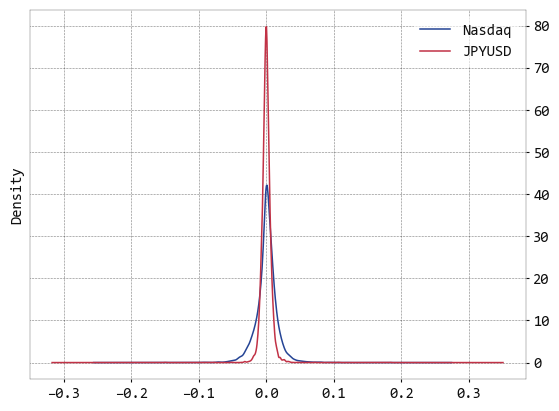

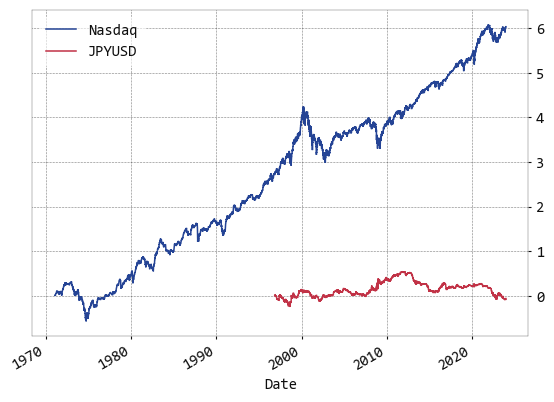

In [22]:
returns_from_prices(df_assets).dropna().plot.density()
returns_from_prices(df_assets).cumsum().plot()

In [23]:
df_all

,2Y,DFF,1Y,Slope2Y,Slope1Y,Slope2Y_sm50,Slope1Y_sm50,Signal,Signal2,Nasdaq,JPYUSD
Date,,,,,,,,,,,
1976-06-01,7.26,5.58,6.70,-1.68,-1.12,-1.680000,-1.124112,-1,1,87.809998,NaN
1976-06-02,7.23,4.90,6.72,-2.33,-1.82,-2.011500,-1.164398,-1,-1,88.160004,NaN
1976-06-03,7.22,5.50,6.73,-1.72,-1.23,-1.910421,-1.168126,1,-1,88.260002,NaN
1976-06-04,7.12,5.44,6.60,-1.68,-1.16,-1.849314,-1.167672,1,1,87.750000,NaN
1976-06-07,7.09,5.45,6.51,-1.64,-1.06,-1.801134,-1.161294,1,1,87.220001,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2023-11-24,4.92,5.33,5.27,0.41,0.06,0.367989,-0.013547,1,1,14250.849609,0.006683
2023-11-27,4.84,5.33,5.24,0.49,0.09,0.375272,-0.007366,1,1,14241.019531,0.006686
2023-11-28,4.73,5.33,5.21,0.60,0.12,0.388416,0.000083,1,1,14281.759766,0.006736


<AxesSubplot: xlabel='Date'>

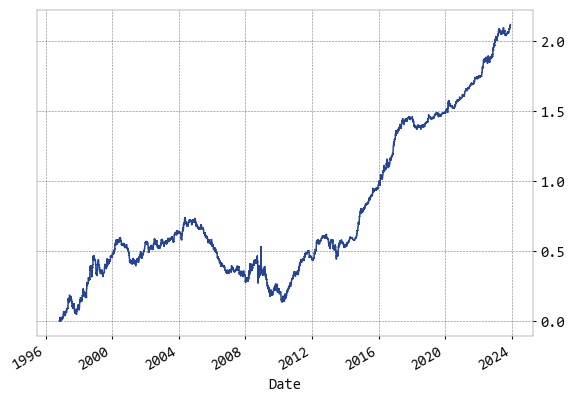

In [28]:
performance(signal=df_all['Signal'], returns=df_all['JPYUSD'].pct_change()).dropna().cumsum().plot()

In [44]:
# performance
# ======================================================================================================================
df_perm = pd.DataFrame(index=df_all.index)
for col in ['JPYUSD']:
    # df_perm[col] = performance(signal=df_all['Signal'], returns=np.log(df_all[col]).diff()).cumsum()
    ret_temp = returns_from_prices(df_all[col])
    df_perm[col] = performance(signal=df_all['Signal'], returns=ret_temp)
    df_perm[col + '_no_TC'] = performance(signal=df_all['Signal'], returns=ret_temp, bps=0)
    # df_perm[col + 'str2'] = performance(signal=df_all['Signal2'], returns=np.log(df_all[col]).diff())

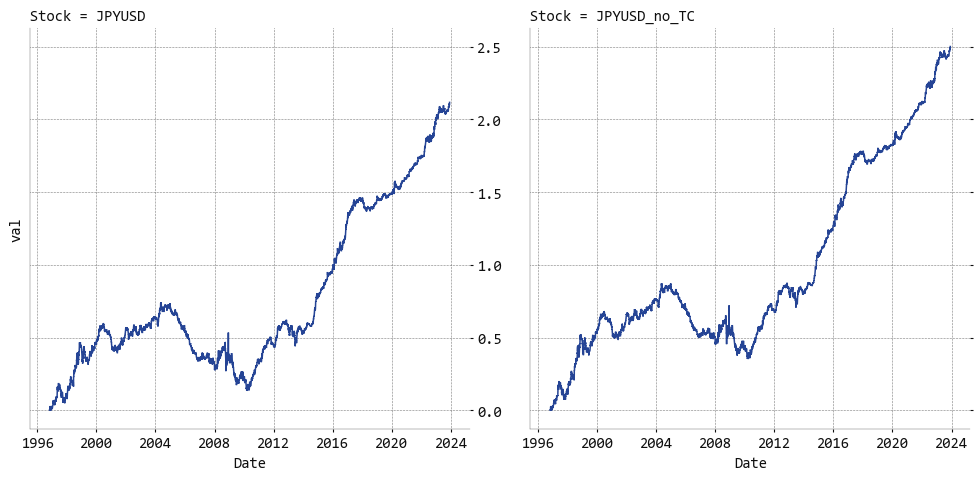

In [45]:
# from wide to long to plot
# ======================================================================================================================
dfm = df_perm.cumsum().dropna().reset_index().melt(id_vars='Date', var_name='Stock', value_name='val')
dfm['asset'] = [x.split('str')[0] for x in dfm.Stock]
g = sns.relplot(data=dfm, x='Date', y='val', col='Stock', col_wrap=3, kind='line')

# stats
df_perm_stats = performance_overview(df_perm, short=True).sort_values(by=['cagr'], ascending=False)

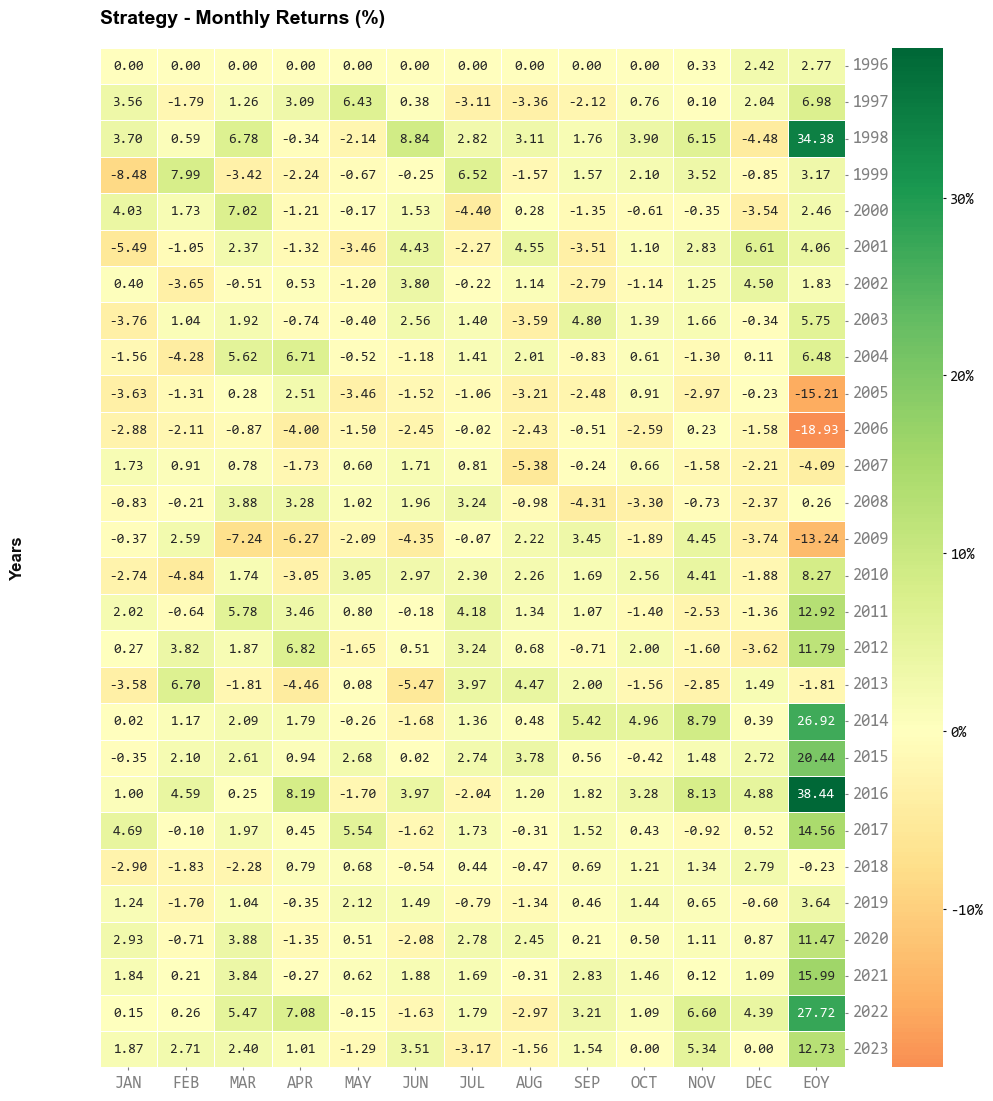

In [31]:
ret_bench = df_stock.pct_change()
df_temp = df_perm[['JPYUSD']].join(ret_bench).dropna()
qs.plots.monthly_returns(df_temp['JPYUSD'], eoy=True)

<AxesSubplot: >

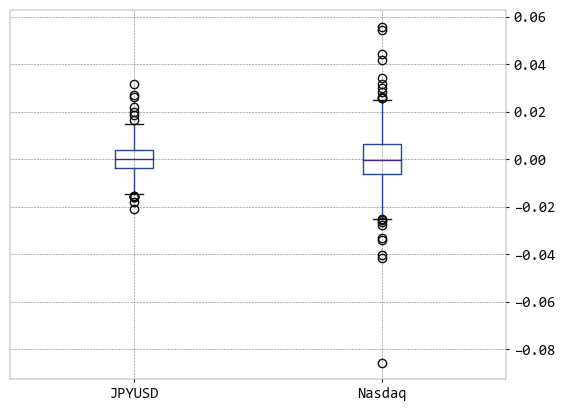

In [36]:
monthly = df_temp.asfreq('BM')
monthly.boxplot()

In [ ]:
monthly_heatmap(df_temp['Nasdaq'], eoy=True)

In [ ]:
get_main_stats(df_temp[df_temp.index>='2012-01-01'])